In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os

In [6]:
disk = 'L:'# disk is Elements on adour
date = '0211'

data_path = f'{disk}/Share_hublot/Data'
daily_drone_data_path = f'{data_path}/{date}/Drones'

velocity_field_path = f'{daily_drone_data_path}/exact_solution_real_field_stereo_0211_2024_rectangular_grid.h5'

# traitement stéphane : postitions des fractures (obtenue avec divergence du champ de vitesses)
fractures_positions_path = f'{daily_drone_data_path}/Results/fracture_positions.pkl'

In [7]:
with open(fractures_positions_path, 'rb') as file:
    fractures_positions_data = pickle.load(file)

In [12]:
path_dict2save = f'{daily_drone_data_path}/Results/traitement_vasco/dict_results_frac.pkl'
if os.path.exists(path_dict2save):
    with open(path_dict2save, 'rb') as file:
        dict_frac = pickle.load(file)


In [13]:
k

'lambda_byhand'

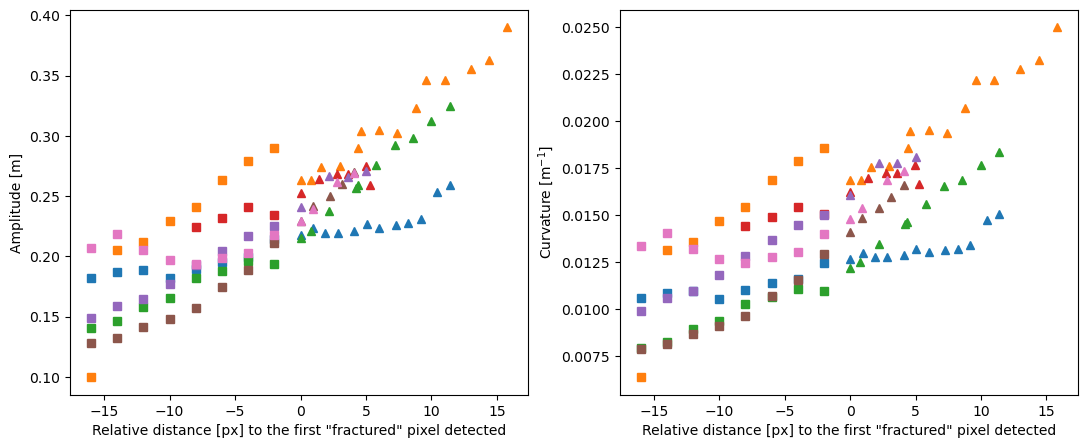

In [28]:
array_frac_id = np.array(dict_frac['lambda_byhand']['list_frac_id'])
array_wavelength = np.array(dict_frac['lambda_byhand']['wavelength'])


fig, axs = plt.subplots(1,2, figsize=(13,5))


colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']



ct = 0
for k in dict_frac:
    if 'single_frac' in k:
        coord_onfracline_cassee = dict_frac[k]['coord_onfracline_cassee']
        coord_onfracline_noncassee = dict_frac[k]['coord_onfracline_noncassee']
        array_amplitudes_frac = dict_frac[k]['array_amplitudes_frac']
        array_amplitudes_ref_noncassee = dict_frac[k]['array_amplitudes_ref_noncassee']

        wave_period_sec = dict_frac[k]['wave_period_sec']




        axs[0].plot(coord_onfracline_noncassee, array_amplitudes_ref_noncassee,'s',color=colors[ct])
        axs[0].plot(coord_onfracline_cassee, array_amplitudes_frac,'^',color=colors[ct])

        axs[0].set_ylabel('Amplitude [m]')
        axs[0].set_xlabel('Relative distance [px] to the first "fractured" pixel detected')

        ######################

        wavelength = array_wavelength[array_frac_id==k][0]
        wavenumber = 2*np.pi/wavelength
        array_kappa_frac = array_amplitudes_frac * wavenumber**2
        array_kappa_noncassee = array_amplitudes_ref_noncassee * wavenumber**2
        
        axs[1].plot(coord_onfracline_noncassee, array_kappa_noncassee,'s',color=colors[ct])
        axs[1].plot(coord_onfracline_cassee, array_kappa_frac,'^',color=colors[ct])

        axs[1].set_ylabel('Curvature [m$^{-1}$]')
        axs[1].set_xlabel('Relative distance [px] to the first "fractured" pixel detected')





        ct+=1




In [1]:
# estimation de la deformation
h_engros = 0.2 #m
kappac_engros = 13e-3
kappac_err_engros = 2e-3

print('epsilon_c =', kappac_engros*h_engros/2, '+-', kappac_err_engros*h_engros/2)


epsilon_c = 0.0013 +- 0.0002


In [4]:
13/1.5

8.666666666666666